# Reading and plotting signals
Read recorded signals from ADI Study Watch and BioNomadix devices. 
Plot ECG, PPG, and accelerometer data from the smartwatch, and ECG from BioNomadix.
Signals must be plotted with x-axis in time, in seconds.

In [1]:
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import scipy
from datetime import timedelta

# Import Pandas only for reading Watch CSV File and for plotting description in Q1
import pandas as pd


# Time domain analysis

In [66]:
def load_bp_csv(filename, start_datetime):
    test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
    test = test.drop(0)
    test = test.drop(test.columns[3], axis=1)  # Drop the first column
    test = test.rename(columns={'milliSec': 'time_ms', 'CH13': 'ecg', 'CH1': 'ppg'})
    test['ecg'] = pd.to_numeric(test['ecg'], errors='coerce')
    test['timestamp'] = pd.to_datetime(start_datetime) + pd.to_timedelta(test['time_ms'], unit='ms')
    return test


def load_watch_ecg(filename):
    df = pd.read_csv(filename, skiprows=2)
    df = df[['Timestamp', 'ECG data']].dropna()
    df.rename(columns={'Timestamp': 'timestamp', 'ECG data': 'ecg'}, inplace=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['ecg'] = pd.to_numeric(df['ecg'], errors='coerce')
    df = df.dropna()

    # Convert to seconds
    df['time_ms'] = (df['timestamp'] - df['timestamp'].iloc[0])
    return df


def load_watch_data(ecg_file, ppg_file):
    ecg_df = pd.read_csv(ecg_file, skiprows=2)
    ppg_df = pd.read_csv(ppg_file, skiprows=2)

    # Rename columns for clarity
    ecg_df.rename(columns={'Timestamp': 'timestamp', 'ECG data': 'ecg'}, inplace=True)
    ppg_df.rename(columns={'PPG Timestamp': 'timestamp', 'PPG data': 'ppg'}, inplace=True)

    # Add column with time in milli seconds
    ecg_df['time_ms'] = (ecg_df['timestamp'] - ecg_df['timestamp'].iloc[0])
    ppg_df['time_ms'] = (ppg_df['timestamp'] - ppg_df['timestamp'].iloc[0])

    latest_start_time = max(ecg_df['timestamp'].iloc[0], ppg_df['timestamp'].iloc[0])
    earliest_end_time = min(ecg_df['timestamp'].iloc[-1], ppg_df['timestamp'].iloc[-1])

    # Filter data to the common time range
    ecg_df = ecg_df[(ecg_df['timestamp'] >= latest_start_time) & (ecg_df['timestamp'] <= earliest_end_time)]
    ppg_df = ppg_df[(ppg_df['timestamp'] >= latest_start_time) & (ppg_df['timestamp'] <= earliest_end_time)]

    # Drop all columns except timestamp, time_ms and ecg/ppg
    ppg_df = ppg_df.drop(columns=['ADXL Timestamp', 'X', 'Y', 'Z'])
    ecg_df = ecg_df.drop(columns=['Seq No.'])
    # Merge ECG and PPG based on the millisecond given
    merged_df = pd.merge_asof(ecg_df.sort_values('timestamp'), ppg_df.sort_values('timestamp'), on='timestamp',
                              direction='nearest')

    merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'], unit='ms')
    return merged_df


def plot_watch_bp_ecg(watch_df, bp_data, start_time, end_time):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    watch_df.sort_values('time_ms_x', inplace=True)
    bp_data.sort_values('time_ms', inplace=True)

    # Select time frame to plot
    # Discard time frames that are not represented in both recordings
    latest_start_time = max(watch_df['timestamp'].iloc[0], bp_data['timestamp'].iloc[0]) # + timedelta(minutes=5)
    earliest_end_time = min(watch_df['timestamp'].iloc[-1], bp_data['timestamp'].iloc[-1])
    watch_df = watch_df[(watch_df['timestamp'] >= latest_start_time) & (watch_df['timestamp'] <= earliest_end_time)]
    watch_df = watch_df[(watch_df['timestamp'] >= start_time) & (watch_df['timestamp'] <= end_time)]
    bp_data = bp_data[(bp_data['timestamp'] >= latest_start_time) & (bp_data['timestamp'] <= earliest_end_time)]
    bp_data = bp_data[(bp_data['timestamp'] >= start_time) & (bp_data['timestamp'] <= end_time)]

    # Plot ECG from Watch
    ax1.plot(watch_df['timestamp'], watch_df['ecg'], label='ECG from Watch', color='blue')
    ax1.set_ylabel('ECG Amplitude')
    ax1.set_xlabel('Time')
    ax1.set_title('ECG Signal from Smartwatch')
    ax1.legend()

    # Plot ECG from BioPac
    ax2.plot(bp_data['timestamp'], bp_data['ecg'], label='ECG from BioPac', color='orange')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('ECG Amplitude')
    ax2.set_title('ECG Signal from BioPac')
    ax2.legend()
    plt.tight_layout()
    plt.show()

def crop_window(data, start_time, end_time):
    data = data[(data['timestamp'] >= start_time) & (data['timestamp'] <= end_time)]
    return data


# Time domain
Consider an ECG signal, using fixed windows of 5s with 50% overlap, compute the following features for a segment of 30s long:
- Mean
- Median
- Variance
- Std Dev
- Skewness
- RMS
- Zero-Crossing Rate
- Energy
- Power

Apply this porcedure to the ECG signals acquired from ADI Study Watch and BioNomadix.

C:\Users\rayva\AppData\Local\Temp\ipykernel_6800\529000191.py:2: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')
C:\Users\rayva\AppData\Local\Temp\ipykernel_6800\529000191.py:2: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(filename, skiprows=8, header=1, delimiter='\t')


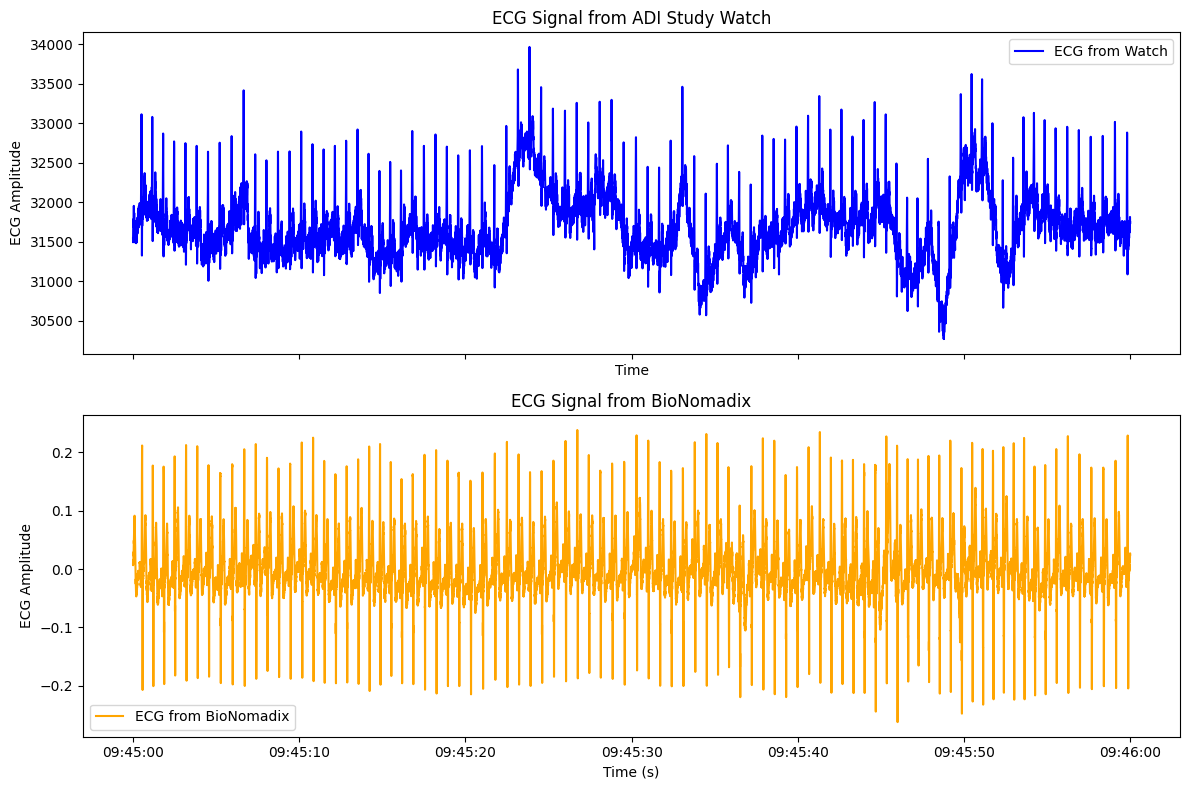

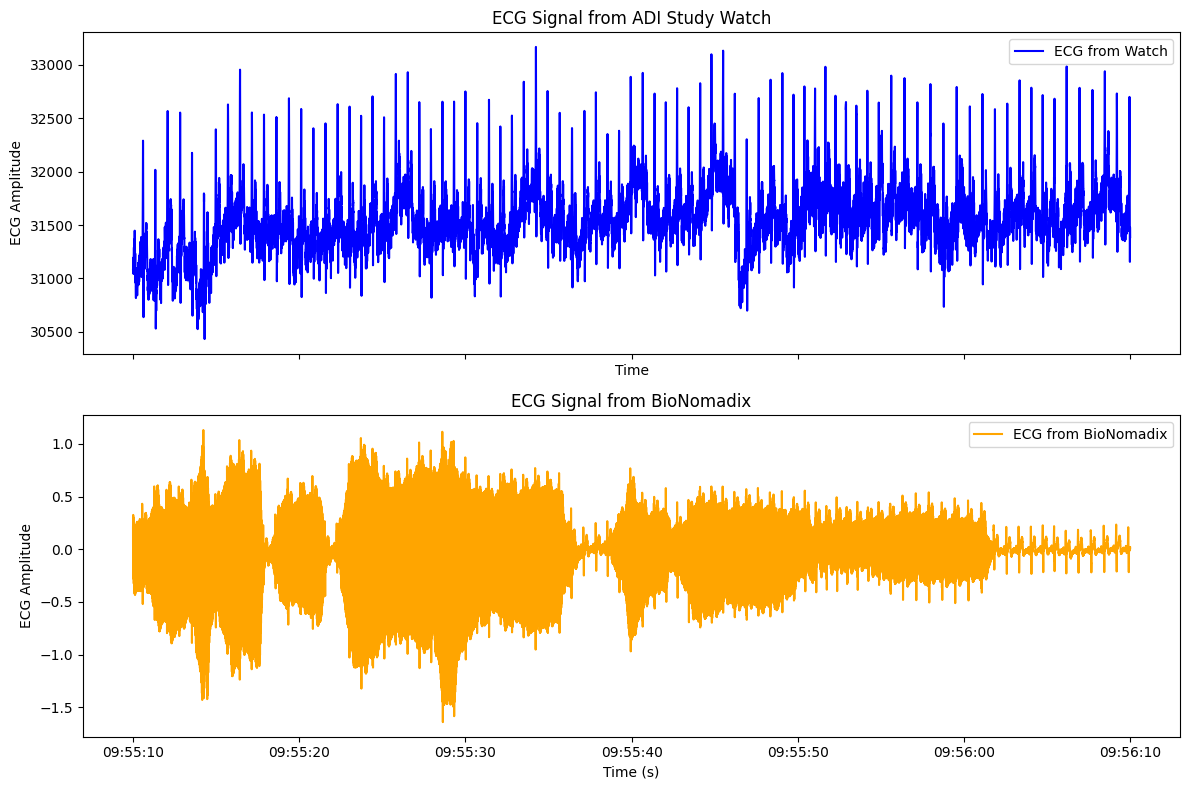

In [34]:
bp_clean = load_bp_csv('data/assignment_2/recording_1_ecgppg_biopac_clean_data.txt',
                        start_datetime=datetime(2025, 5, 22, 9, 43, 51, 760000) - timedelta(seconds=0.75))
bp_noisy = load_bp_csv('data/assignment_2/recording_2_ecgppg_biopac_noisy.txt',
                        start_datetime=datetime(2025, 5, 22, 9, 54, 40, 285000) - timedelta(seconds=0.4))
watch_clean = load_watch_data('data/assignment_2/recording_1_ecg_watch_clean_data.csv',
                              'data/assignment_2/recording_1_ppg_watch_clean_data.csv')
watch_noisy = load_watch_data('data/assignment_2/recording_2_ecg_watch_noisy.csv',
                              'data/assignment_2/recording_2_ppg_watch_noisy.csv')

plot_watch_bp_ecg(watch_clean, bp_clean, '2025-05-22 09:45:00', '2025-05-22 09:46:00')
plot_watch_bp_ecg(watch_noisy, bp_noisy, '2025-05-22 09:55:10', '2025-05-22 09:56:10')


In [51]:
#calculate measurements from watch and bp data

def plot_data_descriptions(watch_df, bp_df, dataset_name='Give Name Please'):
    description_df.loc[len(description_df)] = [
        dataset_name + ' Watch',
        watch_df['ecg'].mean(),
        watch_df['ecg'].median(),
        watch_df['ecg'].var(),
        watch_df['ecg'].std(),
        watch_df['ecg'].skew(),
        np.sqrt(np.mean(watch_df['ecg'] ** 2)),
        np.mean(np.diff(np.sign(watch_df['ecg'])) != 0),
        np.sum(watch_df['ecg'] ** 2),
        np.mean(watch_df['ecg'] ** 2)
    ]
    description_df.loc[len(description_df)] = [
        dataset_name + ' BP',
        bp_df['ecg'].mean(),
        bp_df['ecg'].median(),
        bp_df['ecg'].var(),
        bp_df['ecg'].std(),
        bp_df['ecg'].skew(),
        np.sqrt(np.mean(bp_df['ecg'] ** 2)),
        np.mean(np.diff(np.sign(bp_df['ecg'])) != 0),
        np.sum(bp_df['ecg'] ** 2),
        np.mean(bp_df['ecg'] ** 2)
    ]

In [52]:
# Data Description DF
description_df = pd.DataFrame({
    'Dataset Name': [], 'Mean': [], 'Median': [], 'Variance': [], 'Std Dev': [], 'Skewness': [], 'RMS': [], 'Zero-Crossing Rate': [],
    'Energy': [], 'Power': []
})

# crop 1 minute window for q1a
minute_watch_clean = crop_window(watch_clean,'2025-05-22 09:45:00', '2025-05-22 09:46:00')
minute_watch_noisy =crop_window(watch_noisy, '2025-05-22 09:55:10', '2025-05-22 09:56:10')
minute_bp_clean = crop_window(bp_clean,'2025-05-22 09:45:00', '2025-05-22 09:46:00')
minute_bp_noisy =crop_window(bp_noisy, '2025-05-22 09:55:10', '2025-05-22 09:56:10')

plot_data_descriptions(minute_watch_noisy, minute_bp_noisy, dataset_name='Noisy')
plot_data_descriptions(minute_watch_clean, minute_bp_clean, dataset_name='Clean')

description_df


,Dataset Name,Mean,Median,Variance,Std Dev,Skewness,RMS,Zero-Crossing Rate,Energy,Power
0,Noisy Watch,31563.033518,31537.000000,93461.546035,305.714812,0.737643,31564.514012,0.0000,6.022347e+13,9.963185e+08
1,Noisy BP,0.001727,0.006714,0.135900,0.368646,-0.462944,0.368647,0.0900,8.154151e+03,1.359003e-01
2,Clean Watch,31713.506105,31662.000000,173911.604024,417.027102,0.646132,31716.247858,0.0000,6.080386e+13,1.005920e+09
3,Clean BP,-0.001124,-0.011291,0.002783,0.052757,0.690227,0.052768,0.0225,1.670717e+02,2.784482e-03


In [91]:
# generate timestamps for cropping 10s windows
clean_timestamps = ['2025-05-22 09:45:00', '2025-05-22 09:45:05', '2025-05-22 09:45:10', '2025-05-22 09:45:15', '2025-05-22 09:45:20', '2025-05-22 09:45:25', '2025-05-22 09:45:30', '2025-05-22 09:45:35', '2025-05-22 09:45:40', '2025-05-22 09:45:45', '2025-05-22 09:45:50', '2025-05-22 09:45:55', '2025-05-22 09:46:00']

noisy_timestamps = ['2025-05-22 09:55:00', '2025-05-22 09:55:05', '2025-05-22 09:55:10', '2025-05-22 09:55:15', '2025-05-22 09:55:20', '2025-05-22 09:55:25', '2025-05-22 09:55:30', '2025-05-22 09:55:35', '2025-05-22 09:55:40', '2025-05-22 09:55:45', '2025-05-22 09:55:50', '2025-05-22 09:55:55', '2025-05-22 09:56:00']

# crop 10s windows with overlap
clean_windows = {}
noisy_windows = {}
window_index = 1
while window_index < len(clean_timestamps) - 1:
    clean_windows[window_index] = crop_window(bp_clean, clean_timestamps[window_index - 1], clean_timestamps[window_index + 1])
    noisy_windows[window_index] = crop_window(bp_noisy, noisy_timestamps[window_index - 1], noisy_timestamps[window_index + 1])
    window_index += 1


In [92]:
# calculate measurements for overlapping clean windows
overlap_clean_windows_df = pd.DataFrame({
    'Segment': [], 'Mean': [], 'Median': [], 'Variance': [], 'Std Dev': [], 'Skewness': [], 'RMS': [], 'Zero-Crossing Rate': [],
    'Energy': [], 'Power': []
})

for window in clean_windows:
    overlap_clean_windows_df.loc[len(overlap_clean_windows_df)] = [
        window,
        clean_windows[window]['ecg'].mean(),
        clean_windows[window]['ecg'].median(),
        clean_windows[window]['ecg'].var(),
        clean_windows[window]['ecg'].std(),
        clean_windows[window]['ecg'].skew(),
        np.sqrt(np.mean(clean_windows[window]['ecg'] ** 2)),
        np.mean(np.diff(np.sign(clean_windows[window]['ecg'])) != 0),
        np.sum(clean_windows[window]['ecg'] ** 2),
        np.mean(clean_windows[window]['ecg'] ** 2)
    ]

overlap_clean_windows_df

,Segment,Mean,Median,Variance,Std Dev,Skewness,RMS,Zero-Crossing Rate,Energy,Power
0,1.0,0.001580,-0.008545,0.002539,0.050392,0.765119,0.050414,0.0244,25.418013,0.002542
1,2.0,0.000752,-0.009918,0.002645,0.051430,0.798605,0.051433,0.0199,26.456432,0.002645
2,3.0,-0.006209,-0.017395,0.002703,0.051989,0.855083,0.052355,0.0159,27.413609,0.002741
3,4.0,-0.009176,-0.019531,0.002555,0.050551,0.798503,0.051374,0.0153,26.395971,0.002639
4,5.0,-0.001878,-0.012360,0.002563,0.050629,0.808040,0.050662,0.0212,25.668619,0.002567
5,6.0,0.003915,-0.005341,0.002565,0.050650,0.865878,0.050798,0.0303,25.807196,0.002580
6,7.0,-0.000960,-0.007324,0.002743,0.052372,0.647487,0.052378,0.0276,27.437615,0.002743
7,8.0,-0.005093,-0.013275,0.002821,0.053110,0.578511,0.053351,0.0203,28.466241,0.002846
8,9.0,-0.000647,-0.011139,0.003216,0.056707,0.545286,0.056708,0.0219,32.161129,0.003216
9,10.0,0.003436,-0.004883,0.003393,0.058253,0.392948,0.058352,0.0262,34.052659,0.003405


In [96]:
# calculate measurements for overlapping noisy windows
overlap_noisy_windows_df = pd.DataFrame({
    'Segment': [], 'Mean': [], 'Median': [], 'Variance': [], 'Std Dev': [], 'Skewness': [], 'RMS': [], 'Zero-Crossing Rate': [],
    'Energy': [], 'Power': []
})

for window in noisy_windows:
    overlap_noisy_windows_df.loc[len(overlap_noisy_windows_df)] = [
        window,
        noisy_windows[window]['ecg'].mean(),
        noisy_windows[window]['ecg'].median(),
        noisy_windows[window]['ecg'].var(),
        noisy_windows[window]['ecg'].std(),
        noisy_windows[window]['ecg'].skew(),
        np.sqrt(np.mean(noisy_windows[window]['ecg'] ** 2)),
        np.mean(np.diff(np.sign(noisy_windows[window]['ecg'])) != 0),
        np.sum(noisy_windows[window]['ecg'] ** 2),
        np.mean(noisy_windows[window]['ecg'] ** 2)
    ]

overlap_noisy_windows_df

,Segment,Mean,Median,Variance,Std Dev,Skewness,RMS,Zero-Crossing Rate,Energy,Power
0,1.0,-0.005123,0.042572,0.135223,0.367727,-1.583331,0.367744,0.0892,1352.495245,0.135236
1,2.0,-0.001635,0.065308,0.157946,0.397424,-0.665202,0.397408,0.0992,1579.486693,0.157933
2,3.0,0.001202,0.065002,0.212098,0.460541,-0.458970,0.460520,0.0989,2120.998723,0.212079
3,4.0,0.007151,0.028381,0.233814,0.483543,-0.343120,0.483571,0.0972,2338.646717,0.233841
4,5.0,0.002909,0.061035,0.311566,0.558181,-0.404182,0.558161,0.0982,3115.747787,0.311544
5,6.0,-0.002672,0.105591,0.298978,0.546789,-0.372323,0.546768,0.0999,2989.853058,0.298955
6,7.0,0.003540,0.017395,0.136620,0.369621,-0.305735,0.369620,0.0943,1366.323689,0.136619
7,8.0,0.001528,0.015564,0.083000,0.288098,-0.364476,0.288087,0.0944,830.025924,0.082994
8,9.0,-0.009747,0.035553,0.104304,0.322962,-0.262383,0.323093,0.1001,1043.993423,0.104389
9,10.0,-0.001286,-0.003510,0.070052,0.264673,-0.200434,0.264663,0.0996,700.535436,0.070047


In [97]:
# calculate measurements for no overlap clean windows
no_overlap_clean_windows_df = pd.DataFrame({
    'Segment': [], 'Mean': [], 'Median': [], 'Variance': [], 'Std Dev': [], 'Skewness': [], 'RMS': [], 'Zero-Crossing Rate': [],
    'Energy': [], 'Power': []
})

for window in clean_windows:
    if int(window) % 2 == 1:
        no_overlap_clean_windows_df.loc[len(no_overlap_clean_windows_df)] = [
            window,
            clean_windows[window]['ecg'].mean(),
            clean_windows[window]['ecg'].median(),
            clean_windows[window]['ecg'].var(),
            clean_windows[window]['ecg'].std(),
            clean_windows[window]['ecg'].skew(),
            np.sqrt(np.mean(clean_windows[window]['ecg'] ** 2)),
            np.mean(np.diff(np.sign(clean_windows[window]['ecg'])) != 0),
            np.sum(clean_windows[window]['ecg'] ** 2),
            np.mean(clean_windows[window]['ecg'] ** 2)
        ]

no_overlap_clean_windows_df

,Segment,Mean,Median,Variance,Std Dev,Skewness,RMS,Zero-Crossing Rate,Energy,Power
0,1.0,0.001580,-0.008545,0.002539,0.050392,0.765119,0.050414,0.0244,25.418013,0.002542
1,3.0,-0.006209,-0.017395,0.002703,0.051989,0.855083,0.052355,0.0159,27.413609,0.002741
2,5.0,-0.001878,-0.012360,0.002563,0.050629,0.808040,0.050662,0.0212,25.668619,0.002567
3,7.0,-0.000960,-0.007324,0.002743,0.052372,0.647487,0.052378,0.0276,27.437615,0.002743
4,9.0,-0.000647,-0.011139,0.003216,0.056707,0.545286,0.056708,0.0219,32.161129,0.003216
5,11.0,0.001370,-0.008240,0.002896,0.053813,0.588770,0.053828,0.0240,28.977349,0.002897


In [98]:
# calculate measurements for non-overlapping noisy windows
no_overlap_noisy_windows_df = pd.DataFrame({
    'Segment': [], 'Mean': [], 'Median': [], 'Variance': [], 'Std Dev': [], 'Skewness': [], 'RMS': [], 'Zero-Crossing Rate': [],
    'Energy': [], 'Power': []
})

for window in noisy_windows:
    if int(window) % 2 == 1:
        no_overlap_noisy_windows_df.loc[len(no_overlap_noisy_windows_df)] = [
            window,
            noisy_windows[window]['ecg'].mean(),
            noisy_windows[window]['ecg'].median(),
            noisy_windows[window]['ecg'].var(),
            noisy_windows[window]['ecg'].std(),
            noisy_windows[window]['ecg'].skew(),
            np.sqrt(np.mean(noisy_windows[window]['ecg'] ** 2)),
            np.mean(np.diff(np.sign(noisy_windows[window]['ecg'])) != 0),
            np.sum(noisy_windows[window]['ecg'] ** 2),
            np.mean(noisy_windows[window]['ecg'] ** 2)
        ]

no_overlap_noisy_windows_df

,Segment,Mean,Median,Variance,Std Dev,Skewness,RMS,Zero-Crossing Rate,Energy,Power
0,1.0,-0.005123,0.042572,0.135223,0.367727,-1.583331,0.367744,0.0892,1352.495245,0.135236
1,3.0,0.001202,0.065002,0.212098,0.460541,-0.458970,0.460520,0.0989,2120.998723,0.212079
2,5.0,0.002909,0.061035,0.311566,0.558181,-0.404182,0.558161,0.0982,3115.747787,0.311544
3,7.0,0.003540,0.017395,0.136620,0.369621,-0.305735,0.369620,0.0943,1366.323689,0.136619
4,9.0,-0.009747,0.035553,0.104304,0.322962,-0.262383,0.323093,0.1001,1043.993423,0.104389
5,11.0,0.008232,-0.016174,0.042147,0.205298,0.147684,0.205453,0.0997,422.151076,0.042211


# Frequency domain analysis

In [13]:
# Q2

# Frequency domain 
From the same ECG signals of the previous item, compute the Discrete Fourier Transform and the power spectral density using the functions of periodogram and welch of the scipy.signal library.

In [14]:
# Q3

# Time-frequency domain

In [15]:
# Q4

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def generate_stationary_signals(fs, duration, frequencies):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    return [np.sin(2 * np.pi * freq * t) for freq in frequencies]


def generate_composite_signal(fs, duration, frequencies):
    signal_comp = np.sum(np.stack(generate_stationary_signals(fs, duration, frequencies)), axis=0)
    return signal_comp


def generate_non_stationary_signals(fs,  # Sampling frequency (Hz)
                                    frequencies,  # Frequencies to generate
                                    cycles):
    # Calculate durations and create time array
    segment_durations = [c / f for c, f in zip(cycles, frequencies)]
    total_duration = sum(segment_durations)
    t = np.linspace(0, total_duration, int(fs * total_duration), endpoint=False)
    signal_non_st = np.zeros(len(t))

    # Generate a Non-Stationary signal 
    current_sample = 0
    for freq, n_cycles in zip(frequencies, cycles):
        seg_samples = int(n_cycles / freq * fs)
        local_t = np.arange(seg_samples) / fs
        segment = np.sin(2 * np.pi * freq * local_t)
        signal_non_st[current_sample:current_sample + seg_samples] = segment
        current_sample += seg_samples

    # Create reversed signal
    reversed_signal_non_st = signal_non_st[::-1]

    return signal_non_st, reversed_signal_non_st


stationary_signals = generate_stationary_signals(fs=500, duration=1, frequencies=[10, 25, 50, 100])
comp_signal = generate_composite_signal(fs=500, duration=1, frequencies=[10, 25, 50, 100])
singal_non_st, reversed_signal_non_st = generate_non_stationary_signals(fs=500,  # Sampling frequency (Hz)
                                                                        frequencies=[10, 25, 50, 100],
                                                                        # Frequencies to generate
                                                                        cycles=[3, 6, 12, 25])


In [17]:
# Q5

# Time-frequency-domain analysis

In [18]:
# Q6 

In [19]:
# Q7

In [20]:
# Q8

In [21]:
# Q9

In [22]:
# Q10